In [1]:
#!pip install duckdb

In [2]:
#pip install --upgrade pip

In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import duckdb
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

# run from the Assignment 1 folder (one level up) so paths like data/... and static/... resolve
if not os.path.exists("data"):
    os.chdir("..")

In [4]:
# Query directly and show the results
display(duckdb.sql("SELECT * FROM 'data/lms_loan_daily.csv' LIMIT 5").df())
display(duckdb.sql("SELECT * FROM 'data/features_attributes.csv' LIMIT 5").df())
display(duckdb.sql("SELECT * FROM 'data/features_financials.csv' LIMIT 5").df())
display(duckdb.sql("SELECT * FROM 'data/feature_clickstream.csv' LIMIT 5").df())


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000,0.0,0.0,0.0,10000.0,2023-05-01
1,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2023-06-01
2,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2023-07-01
3,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,3,10000,1000.0,0.0,1000.0,8000.0,2023-08-01
4,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,4,10000,1000.0,2000.0,0.0,6000.0,2023-09-01


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1000,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, and Home Equity Loan",57,26,...,Bad,1562.91,30.077191,10 Years and 9 Months,Yes,42.941090,77.31427572208112,High_spent_Medium_value_payments,400.36080052211616,2023-05-01
1,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",5,18,...,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
2,CUS_0x100b,113781.38999999998,9549.782500,1,4,1,0,None,14,8,...,Good,1030.2,28.592943,15 Years and 10 Months,No,0.000000,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01
3,CUS_0x1011,58918.47,5208.872500,3,3,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27,13,...,Standard,473.14,27.829959,15 Years and 10 Months,Yes,123.434939,383.35084463651407,Low_spent_Medium_value_payments,294.1014665671429,2023-11-01
4,CUS_0x1013,98620.98,7962.415000,3,3,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12,9,...,Good,1233.51,26.524864,17 Years and 10 Months,No,228.018084,332.3337079767732,High_spent_Medium_value_payments,485.8897083704929,2023-12-01


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01


In [5]:
duckdb.sql("""
    SELECT * FROM 'data/features_attributes.csv'
""").df().describe(include="all")

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
count,12500,12500,12500,12500,12500,12500
unique,12500,10139,301,11798,16,NaN
top,CUS_0xffd,Langep,26,#F%$D@*&8,_______,NaN
freq,1,6,364,703,880,NaN
mean,NaN,NaN,NaN,NaN,NaN,2023-12-31 15:19:31.584000
min,NaN,NaN,NaN,NaN,NaN,2023-01-01 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,2023-07-01 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,2024-07-01 00:00:00
max,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:00:00


In [6]:
duckdb.sql("""
    SELECT * FROM 'data/lms_loan_daily.csv'
""").df().describe(include="all")

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
count,137500,137500,137500,137500.0,137500.000000,137500.0,137500.000000,137500.000000,137500.000000,137500.000000,137500
unique,12500,12500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUS_0xffd_2024_03_01,CUS_0xffd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,11,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2023-12-31 15:19:31.584000,10.0,5.000000,10000.0,909.090909,711.810909,871.905455,5871.905455,2024-05-31 21:16:42.554181
min,NaN,NaN,2023-01-01 00:00:00,10.0,0.000000,10000.0,0.000000,0.000000,0.000000,0.000000,2023-01-01 00:00:00
25%,NaN,NaN,2023-07-01 00:00:00,10.0,2.000000,10000.0,1000.000000,0.000000,0.000000,3000.000000,2023-12-01 00:00:00
50%,NaN,NaN,2024-01-01 00:00:00,10.0,5.000000,10000.0,1000.000000,1000.000000,0.000000,7000.000000,2024-06-01 00:00:00
75%,NaN,NaN,2024-07-01 00:00:00,10.0,8.000000,10000.0,1000.000000,1000.000000,0.000000,8000.000000,2024-12-01 00:00:00
max,NaN,NaN,2025-01-01 00:00:00,10.0,10.000000,10000.0,1000.000000,4000.000000,10000.000000,10000.000000,2025-11-01 00:00:00


In [7]:
duckdb.sql("""
    SELECT * FROM 'data/features_financials.csv'
""").df().describe(include="all")

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
count,12500,12500,12500.000000,12500.000000,12500.000000,12500.000000,12500,11074,12500.000000,12500,...,12500,12500,12500.000000,12500,12500,12500.000000,12500,12500,12500,12500
unique,12500,12492,NaN,NaN,NaN,NaN,87,6260,NaN,168,...,4,12213,NaN,393,3,NaN,11921,7,12500,26
top,CUS_0xffd,17273.83,NaN,NaN,NaN,NaN,3,Not Specified,NaN,19,...,Standard,1360.45,NaN,16 Years and 2 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,389.434630761722,2024-08-01
freq,1,2,NaN,NaN,NaN,NaN,1808,176,NaN,735,...,4497,3,NaN,79,6571,NaN,558,3202,1,543
mean,NaN,NaN,4188.592303,16.939920,23.172720,73.213360,NaN,NaN,21.060880,NaN,...,NaN,NaN,32.349265,NaN,NaN,1488.394291,NaN,NaN,NaN,NaN
std,NaN,NaN,3180.147611,114.350815,132.005866,468.682227,NaN,NaN,14.863091,NaN,...,NaN,NaN,5.156815,NaN,NaN,8561.449910,NaN,NaN,NaN,NaN
min,NaN,NaN,303.645417,-1.000000,0.000000,1.000000,NaN,NaN,-5.000000,NaN,...,NaN,NaN,20.100770,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,1624.937917,3.000000,4.000000,8.000000,NaN,NaN,10.000000,NaN,...,NaN,NaN,28.066517,NaN,NaN,31.496968,NaN,NaN,NaN,NaN
50%,NaN,NaN,3087.595000,6.000000,5.000000,14.000000,NaN,NaN,18.000000,NaN,...,NaN,NaN,32.418953,NaN,NaN,72.887628,NaN,NaN,NaN,NaN
75%,NaN,NaN,5947.364167,7.000000,7.000000,20.000000,NaN,NaN,28.000000,NaN,...,NaN,NaN,36.623650,NaN,NaN,169.634826,NaN,NaN,NaN,NaN


In [8]:
duckdb.sql("""
    SELECT * FROM 'data/feature_clickstream.csv'
""").df().describe(include="all")

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
count,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,...,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376,215376
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8974,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CUS_0xfe4,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,NaN
mean,101.414796,103.096195,104.333709,105.648503,106.996676,103.235922,107.070337,110.718724,114.406354,117.775797,...,100.420804,100.025801,99.600383,99.860834,100.129425,100.125139,100.341162,100.046259,NaN,2023-12-16 10:00:00
min,-378.000000,-356.000000,-399.000000,-307.000000,-343.000000,-321.000000,-368.000000,-361.000000,-328.000000,-317.000000,...,-355.000000,-394.000000,-351.000000,-342.000000,-329.000000,-344.000000,-401.000000,-354.000000,NaN,2023-01-01 00:00:00
25%,34.000000,36.000000,36.000000,38.000000,39.000000,36.000000,39.000000,43.000000,47.000000,50.000000,...,33.000000,32.000000,31.000000,32.000000,32.000000,31.000000,31.000000,30.000000,NaN,2023-06-23 12:00:00
50%,102.000000,103.000000,104.000000,106.000000,107.000000,103.000000,107.000000,111.000000,115.000000,118.000000,...,101.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,2023-12-16 12:00:00
75%,169.000000,171.000000,172.000000,173.000000,175.000000,171.000000,174.000000,179.000000,182.000000,186.000000,...,168.000000,168.000000,168.000000,168.000000,169.000000,169.000000,170.000000,170.000000,NaN,2024-06-08 12:00:00
max,541.000000,560.000000,583.000000,562.000000,570.000000,565.000000,537.000000,573.000000,577.000000,537.000000,...,530.000000,583.000000,597.000000,554.000000,516.000000,551.000000,560.000000,547.000000,NaN,2024-12-01 00:00:00


## SANITY CHECKS

In [9]:
duckdb.sql(
    "\
    SELECT COUNT(tenure) AS tenure_lengths, tenure\
    FROM 'data/lms_loan_daily.csv'\
    GROUP BY tenure\
    ")

┌────────────────┬────────┐
│ tenure_lengths │ tenure │
│     int64      │ int64  │
├────────────────┼────────┤
│         137500 │     10 │
└────────────────┴────────┘

In [10]:
duckdb.sql(
    "\
    SELECT COUNT(installment_num) AS installment_num_lengths, installment_num\
    FROM 'data/lms_loan_daily.csv'\
    GROUP BY installment_num\
    ORDER BY installment_num\
    ")

┌─────────────────────────┬─────────────────┐
│ installment_num_lengths │ installment_num │
│          int64          │      int64      │
├─────────────────────────┼─────────────────┤
│                   12500 │               0 │
│                   12500 │               1 │
│                   12500 │               2 │
│                   12500 │               3 │
│                   12500 │               4 │
│                   12500 │               5 │
│                   12500 │               6 │
│                   12500 │               7 │
│                   12500 │               8 │
│                   12500 │               9 │
│                   12500 │              10 │
└─────────────────────────┴─────────────────┘
  11 rows                         2 columns

In [11]:
duckdb.sql(
    "\
    SELECT COUNT(Occupation) AS Occupation_lengths, Occupation\
    FROM 'data/features_attributes.csv'\
    GROUP BY Occupation\
    ORDER BY Occupation\
    ")

┌────────────────────┬───────────────┐
│ Occupation_lengths │  Occupation   │
│       int64        │    varchar    │
├────────────────────┼───────────────┤
│                791 │ Accountant    │
│                795 │ Architect     │
│                780 │ Developer     │
│                760 │ Doctor        │
│                793 │ Engineer      │
│                776 │ Entrepreneur  │
│                761 │ Journalist    │
│                828 │ Lawyer        │
│                736 │ Manager       │
│                780 │ Mechanic      │
│                780 │ Media_Manager │
│                741 │ Musician      │
│                789 │ Scientist     │
│                782 │ Teacher       │
│                728 │ Writer        │
│                880 │ _______       │
└────────────────────┴───────────────┘
  16 rows                  2 columns

In [12]:
duckdb.sql("""
    WITH cleaned_age AS (
        SELECT
            Age AS original_age,
            TRY_CAST(rtrim(Age, '_') AS INTEGER) AS Age2
        FROM 'data/features_attributes.csv'
    )
    SELECT original_age, Age2
    FROM cleaned_age
    WHERE Age2 BETWEEN 1 AND 100
       OR Age2 IS NULL
    ORDER BY Age2
""")

┌────────────────┬───────┐
│  original_age  │ Age2  │
│    varchar     │ int32 │
├────────────────┼───────┤
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ 14             │    14 │
│ ·              │     · │
│ ·              │     · │
│ ·              │     · │
│ 44             │    44 │
│ 44             │    44 │
│ 44             │    44 │
│ 44             │    44 │
│ 44             │    44 │
│ 44_            │    44 │
│ 44             │    44 │
│ 44             │    44 │
│ 44             │    44 │
│ 45             │    45 │
└────────────────┴───────┘
  ? rows       2 columns
  (>9999 rows, 20 shown) 

In [13]:
duckdb.sql("""
    WITH cleaned_age AS (
        SELECT TRY_CAST(rtrim(Age, '_') AS INTEGER) AS Age
        FROM 'data/features_attributes.csv'
    )
    SELECT Age, COUNT(Age) AS age_counts
    FROM cleaned_age
    WHERE Age BETWEEN 1 AND 100
    GROUP BY Age
    ORDER BY Age
""").df()

,Age,age_counts
0,14,87
1,15,195
2,16,189
3,17,198
4,18,241
5,19,353
6,20,358
7,21,335
8,22,346
9,23,318


In [14]:
duckdb.sql("""
    WITH cleaned_age AS (
        SELECT
            Age AS original_age,
            TRY_CAST(rtrim(Age, '_') AS INTEGER) AS Age2
        FROM 'data/features_attributes.csv'
    )
    SELECT original_age, Age2
    FROM cleaned_age
    WHERE Age2 NOT BETWEEN 1 AND 100
       OR Age2 IS NULL
    ORDER BY Age2
""")

┌──────────────┬───────┐
│ original_age │ Age2  │
│   varchar    │ int32 │
├──────────────┼───────┤
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│ -500         │  -500 │
│  ·           │    ·  │
│  ·           │    ·  │
│  ·           │    ·  │
│ 8442         │  8442 │
│ 8448         │  8448 │
│ 8467         │  8467 │
│ 8547         │  8547 │
│ 8566         │  8566 │
│ 8623         │  8623 │
│ 8628         │  8628 │
│ 8663         │  8663 │
│ 8669_        │  8669 │
│ 8678         │  8678 │
└──────────────┴───────┘
  319 rows   2 columns
  (20 shown)           

In [15]:
duckdb.sql(
    "\
    SELECT Payment_Behaviour, COUNT(Payment_Behaviour) AS Payment_Behaviour_Types\
    FROM 'data/features_financials.csv'\
    GROUP BY Payment_Behaviour\
    ORDER BY Payment_Behaviour\
    ")

┌──────────────────────────────────┬─────────────────────────┐
│        Payment_Behaviour         │ Payment_Behaviour_Types │
│             varchar              │          int64          │
├──────────────────────────────────┼─────────────────────────┤
│ !@9#%8                           │                     998 │
│ High_spent_Large_value_payments  │                    1683 │
│ High_spent_Medium_value_payments │                    2242 │
│ High_spent_Small_value_payments  │                    1389 │
│ Low_spent_Large_value_payments   │                    1300 │
│ Low_spent_Medium_value_payments  │                    1686 │
│ Low_spent_Small_value_payments   │                    3202 │
└──────────────────────────────────┴─────────────────────────┘

In [16]:
duckdb.sql(
    "\
    SELECT Credit_Mix, COUNT(Credit_Mix) AS counts\
    FROM 'data/features_financials.csv'\
    GROUP BY Credit_Mix\
    ORDER BY Credit_Mix\
    ")

┌────────────┬────────┐
│ Credit_Mix │ counts │
│  varchar   │ int64  │
├────────────┼────────┤
│ Bad        │   2360 │
│ Good       │   3032 │
│ Standard   │   4497 │
│ _          │   2611 │
└────────────┴────────┘

In [17]:
duckdb.sql(
    "\
    SELECT Credit_Mix, COUNT(Credit_Mix) AS Credit_Mix\
    FROM 'data/features_financials.csv'\
    GROUP BY Credit_Mix\
    ORDER BY Credit_Mix\
    ")

┌────────────┬────────────┐
│ Credit_Mix │ Credit_Mix │
│  varchar   │   int64    │
├────────────┼────────────┤
│ Bad        │       2360 │
│ _          │       2611 │
│ Good       │       3032 │
│ Standard   │       4497 │
└────────────┴────────────┘

In [18]:

duckdb.sql(
    "\
    SELECT Type_of_Loan, COUNT(Type_of_Loan) AS counts\
    FROM 'data/features_financials.csv'\
    GROUP BY Type_of_Loan\
    ORDER BY Type_of_Loan\
    ")

┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────┐
│                                                               Type_of_Loan                                                               │ counts │
│                                                                 varchar                                                                  │ int64  │
├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────┤
│ Auto Loan                                                                                                                                │    144 │
│ Auto Loan, Auto Loan, Auto Loan, Auto Loan, Credit-Builder Loan, Credit-Builder Loan, Mortgage Loan, and Personal Loan                   │      1 │
│ Auto Loan, Auto Loan, Auto Loan, Auto Loan, Student Loan, and Student Loan                        

In [19]:
duckdb.sql("""
    WITH expanded_loans AS (
        SELECT
            Customer_ID,
            TRIM(loan_type) AS loan_type
        FROM 'data/features_financials.csv'
        CROSS JOIN UNNEST(
            string_split(
                replace(Type_of_Loan, ', and ', ', '),
                ', '
            )
        ) AS split_values(loan_type)
        WHERE Type_of_Loan IS NOT NULL
    )
    SELECT
        loan_type,
        COUNT(*) AS loan_mentions,
        COUNT(DISTINCT Customer_ID) AS customer_count
    FROM expanded_loans
    GROUP BY loan_type
    ORDER BY customer_count DESC
""").df()

,loan_type,loan_mentions,customer_count
0,Payday Loan,5071,3993
1,Credit-Builder Loan,5055,3966
2,Not Specified,4952,3960
3,Home Equity Loan,4888,3925
4,Mortgage Loan,4867,3920
5,Personal Loan,4861,3888
6,Debt Consolidation Loan,4847,3880
7,Student Loan,4871,3880
8,Auto Loan,4749,3820


In [20]:
result = duckdb.sql("""
    WITH financials AS (
        SELECT
            Customer_ID,
            Type_of_Loan,
            Num_of_Loan AS raw_num_of_loan,
            TRY_CAST(rtrim(Num_of_Loan, '_') AS INTEGER) AS num_of_loan
        FROM 'data/features_financials.csv'
    ),

    expanded_loans AS (
        SELECT
            Customer_ID,
            TRIM(loan_type) AS loan_type
        FROM financials
        CROSS JOIN UNNEST(
            string_split(
                replace(Type_of_Loan, ', and ', ', '),
                ', '
            )
        ) AS split_values(loan_type)
        WHERE Type_of_Loan IS NOT NULL
    ),

    loan_counts AS (
        SELECT
            Customer_ID,
            COUNT(*) AS listed_loan_count
        FROM expanded_loans
        GROUP BY Customer_ID
    ),

    comparison AS (
        SELECT
            f.Customer_ID,
            f.Type_of_Loan,
            f.raw_num_of_loan,
            f.num_of_loan,
            COALESCE(c.listed_loan_count, 0) AS listed_loan_count,
            f.num_of_loan
                - COALESCE(c.listed_loan_count, 0) AS count_difference,
            CASE
                WHEN f.num_of_loan IS NULL
                    THEN 'Invalid Num_of_Loan'
                WHEN f.num_of_loan =
                     COALESCE(c.listed_loan_count, 0)
                    THEN 'Match'
                ELSE 'Mismatch'
            END AS validation_result
        FROM financials AS f
        LEFT JOIN loan_counts AS c
            ON f.Customer_ID = c.Customer_ID
    )

    SELECT *
    FROM comparison
    WHERE count_difference > 0
    ORDER BY count_difference DESC
""").df()

pd.set_option("display.max_rows", None)
display(result)

,Customer_ID,Type_of_Loan,raw_num_of_loan,num_of_loan,listed_loan_count,count_difference,validation_result
0,CUS_0x90cf,"Student Loan, Credit-Builder Loan, and Home Eq...",1495,1495,3,1492,Mismatch
1,CUS_0xa7e9,None,1478,1478,0,1478,Mismatch
2,CUS_0x6c24,"Mortgage Loan, Home Equity Loan, Auto Loan, Mo...",1480,1480,6,1474,Mismatch
3,CUS_0x532a,"Mortgage Loan, and Student Loan",1433,1433,2,1431,Mismatch
4,CUS_0x8b5b,None,1430,1430,0,1430,Mismatch
5,CUS_0x33d6,Payday Loan,1412,1412,1,1411,Mismatch
6,CUS_0x6ee8,"Not Specified, Mortgage Loan, Student Loan, an...",1393,1393,4,1389,Mismatch
7,CUS_0x396c,"Home Equity Loan, Credit-Builder Loan, Not Spe...",1384,1384,5,1379,Mismatch
8,CUS_0x62a6,Payday Loan,1348,1348,1,1347,Mismatch
9,CUS_0xa2dd,"Debt Consolidation Loan, Payday Loan, and Stud...",1320,1320,3,1317,Mismatch


In [21]:
duckdb.sql("""
    SELECT *
    FROM 'data/features_financials.csv'
    WHERE Customer_ID = 'CUS_0xa7e9'
""").df()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0xa7e9,19081.51,1336.125833,8,7,9,1478,None,8,17,...,Standard,1041.07,34.085308,31 Years and 10 Months,Yes,0.0,146.95908792660978,Low_spent_Large_value_payments,327.73027233227907,2023-11-01


In [22]:
duckdb.sql("""
    SELECT *
    FROM 'data/features_financials.csv'
    WHERE Customer_ID = 'CUS_0xb450'
""").df()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0xb450,580744.0,2911.420833,1,2,9,365,Personal Loan,13,8,...,Good,1365.41,26.641453,25 Years and 5 Months,No,15.805627,46.42576437523685,High_spent_Medium_value_payments,478.91069242686564,2023-10-01


In [23]:
duckdb.sql("""
    SELECT
        Customer_ID,
        Num_of_Loan,
        Type_of_Loan,
        Total_EMI_per_month,
        Outstanding_Debt
    FROM 'data/features_financials.csv'
    WHERE TRY_CAST(rtrim(Num_of_Loan, '_') AS INTEGER) = 0
      AND Type_of_Loan IS NULL
""").df()


pd.set_option("display.max_rows", 16)
display(result)

,Customer_ID,Type_of_Loan,raw_num_of_loan,num_of_loan,listed_loan_count,count_difference,validation_result
0,CUS_0x90cf,"Student Loan, Credit-Builder Loan, and Home Eq...",1495,1495,3,1492,Mismatch
1,CUS_0xa7e9,None,1478,1478,0,1478,Mismatch
2,CUS_0x6c24,"Mortgage Loan, Home Equity Loan, Auto Loan, Mo...",1480,1480,6,1474,Mismatch
3,CUS_0x532a,"Mortgage Loan, and Student Loan",1433,1433,2,1431,Mismatch
4,CUS_0x8b5b,None,1430,1430,0,1430,Mismatch
...,...,...,...,...,...,...,...
62,CUS_0x1a9f,"Not Specified, Personal Loan, Mortgage Loan, M...",55,55,5,50,Mismatch
63,CUS_0x382d,"Not Specified, Auto Loan, Auto Loan, and Not S...",33,33,4,29,Mismatch
64,CUS_0x5597,"Student Loan, Not Specified, and Debt Consolid...",31,31,3,28,Mismatch
65,CUS_0x45d2,"Debt Consolidation Loan, Credit-Builder Loan, ...",27_,27,3,24,Mismatch


In [24]:
result = duckdb.sql("""
    SELECT 
        Num_Credit_Inquiries, COUNT(Num_Credit_Inquiries) AS Num_Credit_Inquiries_count
    FROM 'data/features_financials.csv'
    GROUP BY Num_Credit_Inquiries
    ORDER BY Num_Credit_Inquiries
""").df()


pd.set_option("display.max_rows", None)
display(result)

,Num_Credit_Inquiries,Num_Credit_Inquiries_count
0,0.0,543
1,1.0,673
2,2.0,822
3,3.0,1000
4,4.0,1258
5,5.0,990
6,6.0,1080
7,7.0,1045
8,8.0,1007
9,9.0,813


In [25]:
result = duckdb.sql("""
    SELECT 
        Interest_Rate, COUNT(Interest_Rate) AS Interest_Rate_count
    FROM 'data/features_financials.csv'
    GROUP BY Interest_Rate
    ORDER BY Interest_Rate
""").df()


pd.set_option("display.max_rows", None)
display(result)

,Interest_Rate,Interest_Rate_count
0,1,336
1,2,306
2,3,346
3,4,327
4,5,619
5,6,582
6,7,561
7,8,628
8,9,559
9,10,563


In [26]:
result = duckdb.sql("""
    SELECT 
        Credit_Mix, COUNT(Credit_Mix) AS Credit_Mix_count
    FROM 'data/features_financials.csv'
    GROUP BY Credit_Mix
    ORDER BY Credit_Mix
""").df()


pd.set_option("display.max_rows", None)
display(result)

,Credit_Mix,Credit_Mix_count
0,Bad,2360
1,Good,3032
2,Standard,4497
3,_,2611


In [27]:
result = duckdb.sql("""
    SELECT 
        Outstanding_Debt
    FROM 'data/features_financials.csv'
    WHERE TRY_CAST(trim(trim(Outstanding_Debt), '_') AS DOUBLE) < 0
""").df()


pd.set_option("display.max_rows", None)
display(result)

,Outstanding_Debt


## Checks for silver cleaning

These additional queries leave the raw CSVs unchanged. Missing loan lists mean unknown, not confirmed zero loans. The silver rules retain customer rows and flag questionable counts. Age 1–100 and interest rate 0–34 are your current assignment bounds.

In [28]:
# Compare all listed entries, including repeated loan types
result = duckdb.sql("""
    WITH financials AS (
        SELECT Customer_ID, Num_of_Loan AS raw_num_of_loan,
            TRY_CAST(trim(trim(Num_of_Loan), '_') AS INTEGER) AS num_of_loan,
            CASE WHEN Type_of_Loan IS NOT NULL AND trim(Type_of_Loan) <> ''
                THEN len(string_split(replace(Type_of_Loan, ', and ', ', '), ', '))
            END AS listed_loan_count
        FROM 'data/features_financials.csv'
    ),
    comparison AS (
        SELECT *,
            CASE
                WHEN num_of_loan IS NULL OR num_of_loan < 0 THEN 'Invalid count'
                WHEN listed_loan_count IS NULL THEN 'Missing loan list'
                WHEN num_of_loan = listed_loan_count THEN 'Match'
                ELSE 'Mismatch'
            END AS loan_count_status
        FROM financials
    )
    SELECT loan_count_status, COUNT(*) AS row_count
    FROM comparison
    GROUP BY loan_count_status
    ORDER BY row_count DESC
""").df()
display(result)

,loan_count_status,row_count
0,Match,10570
1,Missing loan list,1373
2,Invalid count,500
3,Mismatch,57


In [29]:
# Check field validity, without dropping customer rows
result = duckdb.sql("""
    WITH financials AS (
        SELECT
            TRY_CAST(trim(trim(Interest_Rate), '_') AS DOUBLE) AS interest_rate,
            TRY_CAST(trim(trim(Outstanding_Debt), '_') AS DOUBLE) AS debt,
            Credit_Mix, Payment_of_Min_Amount, snapshot_date
        FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    )
    SELECT
        COUNT(*) AS rows,
        COUNT(*) FILTER (WHERE interest_rate NOT BETWEEN 0 AND 34 OR interest_rate IS NULL)
            AS invalid_interest_rate,
        COUNT(*) FILTER (WHERE debt < 0) AS negative_debt,
        COUNT(*) FILTER (WHERE Credit_Mix IS NULL OR Credit_Mix NOT IN ('Good', 'Standard', 'Bad'))
            AS unknown_credit_mix,
        COUNT(*) FILTER (WHERE Payment_of_Min_Amount IS NULL OR Payment_of_Min_Amount NOT IN ('Yes', 'No'))
            AS unknown_minimum_payment,
        COUNT(*) FILTER (WHERE TRY_CAST(snapshot_date AS DATE) IS NULL) AS invalid_dates
    FROM financials
""").df()
display(result)

,rows,invalid_interest_rate,negative_debt,unknown_credit_mix,unknown_minimum_payment,invalid_dates
0,12500,270,0,2611,1438,1


In [30]:
# Inspect dates that bronze's date filter could exclude
duckdb.sql("""
    SELECT Customer_ID, snapshot_date
    FROM 'data/features_financials.csv'
    WHERE TRY_CAST(snapshot_date AS DATE) IS NULL
""").df()

,Customer_ID,snapshot_date
0,CUS_0x1032,2023-08-x01


In [31]:
# Valid and invalid ages after removing trailing underscores
duckdb.sql("""
    WITH ages AS (
        SELECT TRY_CAST(rtrim(trim(Age), '_') AS INTEGER) AS age
        FROM 'data/features_attributes.csv'
    )
    SELECT COUNT(*) AS rows,
        COUNT(*) FILTER (WHERE age BETWEEN 1 AND 100) AS valid_ages,
        COUNT(*) FILTER (WHERE age IS NULL OR age NOT BETWEEN 1 AND 100) AS invalid_ages
    FROM ages
""").df()

,rows,valid_ages,invalid_ages
0,12500,12181,319


In [32]:
# Valid and invalid ages after removing trailing underscores
duckdb.sql("""
    SELECT
        Payment_Behaviour,
        COUNT(Payment_Behaviour) AS Payment_Behaviour_count
    FROM 'data/features_financials.csv'
    GROUP BY Payment_Behaviour
""").df()

,Payment_Behaviour,Payment_Behaviour_count
0,Low_spent_Medium_value_payments,1686
1,High_spent_Medium_value_payments,2242
2,!@9#%8,998
3,Low_spent_Small_value_payments,3202
4,Low_spent_Large_value_payments,1300
5,High_spent_Small_value_payments,1389
6,High_spent_Large_value_payments,1683


## Checks for valid ranges and placeholders

These queries support the silver rules in `static/valid_ranges.yaml`. Values outside a range are set to null in silver and flagged as `<column>_invalid`; placeholders are set to null.

In [33]:
# Distribution of Amount_invested_monthly, keeping the __10000__ placeholder as its own bucket
duckdb.sql("""
    WITH invested AS (
        SELECT
            trim(Amount_invested_monthly) AS raw_value,
            TRY_CAST(trim(trim(Amount_invested_monthly), '_') AS DOUBLE) AS amount
        FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    )
    SELECT
        CASE
            WHEN raw_value = '__10000__' THEN '__10000__ placeholder'
            WHEN amount < 100 THEN '0-100'
            WHEN amount < 250 THEN '100-250'
            WHEN amount < 500 THEN '250-500'
            WHEN amount < 1000 THEN '500-1000'
            ELSE '1000+'
        END AS bucket,
        COUNT(*) AS rows,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct,
        ROUND(MIN(amount), 1) AS min_amount,
        ROUND(MEDIAN(amount), 1) AS median_amount,
        ROUND(MAX(amount), 1) AS max_amount
    FROM invested
    GROUP BY bucket
    ORDER BY MIN(amount)
""").df()

,bucket,rows,pct,min_amount,median_amount,max_amount
0,0-100,4593,36.7,0.0,60.7,99.9
1,100-250,4635,37.1,100.0,150.7,250.0
2,250-500,1768,14.1,250.0,332.2,498.8
3,500-1000,817,6.5,500.1,639.8,999.9
4,1000+,129,1.0,1000.3,1129.6,1977.3
5,__10000__ placeholder,558,4.5,10000.0,10000.0,10000.0


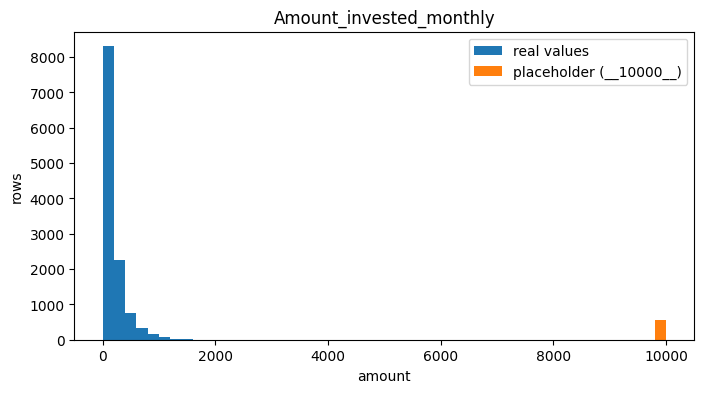

In [34]:
# Amount_invested_monthly: real values end below 2000; the placeholder is a separate spike at 10000
invested = duckdb.sql("""
    SELECT
        trim(Amount_invested_monthly) = '__10000__' AS is_placeholder,
        TRY_CAST(trim(trim(Amount_invested_monthly), '_') AS DOUBLE) AS amount
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
""").df()

plt.figure(figsize=(8, 4))
bins = np.linspace(0, 10000, 51)
plt.hist(invested.amount[~invested.is_placeholder], bins=bins, label="real values")
plt.hist(invested.amount[invested.is_placeholder], bins=bins, label="placeholder (__10000__)")
plt.title("Amount_invested_monthly")
plt.xlabel("amount")
plt.ylabel("rows")
plt.legend()
plt.show()

In [35]:
# Num_Credit_Inquiries is stored as '4.0'; Spark's try_cast to int returns null for these,
# so silver removes the '.0' first. Every value ends in '.0', so nothing is lost.
duckdb.sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(*) FILTER (WHERE Num_Credit_Inquiries LIKE '%.%') AS stored_with_decimal,
        COUNT(*) FILTER (WHERE Num_Credit_Inquiries LIKE '%.0') AS ending_in_point_zero
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
""").df()

,rows,stored_with_decimal,ending_in_point_zero
0,12500,12500,12500


In [36]:
# Rows inside and outside the valid ranges in static/valid_ranges.yaml
import yaml

with open("static/valid_ranges.yaml") as file:
    valid_ranges = yaml.safe_load(file)

range_checks = []
for column, (low, high) in valid_ranges["value_ranges"].items():
    range_checks.append(duckdb.sql(f"""
        WITH financials AS (
            SELECT TRY_CAST(regexp_replace(trim(trim({column}), '_'), '\\.0$', '') AS DOUBLE) AS value
            FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
        )
        SELECT
            '{column}' AS column_name,
            {low} AS low,
            {high} AS high,
            COUNT(*) FILTER (WHERE value BETWEEN {low} AND {high}) AS in_range,
            COUNT(*) FILTER (WHERE value < {low}) AS below_range,
            COUNT(*) FILTER (WHERE value > {high}) AS above_range,
            MAX(value) AS max_value
        FROM financials
    """).df())
range_summary = pd.concat(range_checks, ignore_index=True)
range_summary

,column_name,low,high,in_range,below_range,above_range,max_value
0,Interest_Rate,0,34,12230,0,270,5789.0
1,Num_Bank_Accounts,0,11,12329,4,167,1756.0
2,Num_Credit_Card,0,11,12204,0,296,1499.0
3,Num_Credit_Inquiries,0,17,12305,0,195,2554.0
4,Num_of_Delayed_Payment,0,28,12311,84,105,4293.0


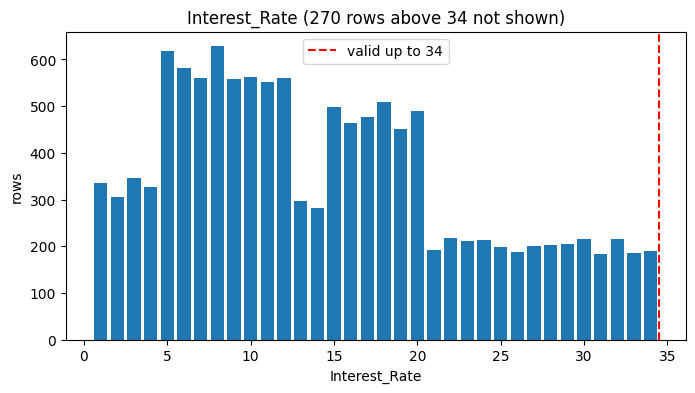

In [37]:
# Interest_Rate: counts of values up to 40; valid values stop at 34
interest_rate = duckdb.sql("""
    SELECT TRY_CAST(trim(trim(Interest_Rate), '_') AS DOUBLE) AS value, COUNT(*) AS rows
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    GROUP BY value
    HAVING value BETWEEN -5 AND 40
""").df()
above = range_summary.set_index("column_name").above_range["Interest_Rate"]

plt.figure(figsize=(8, 4))
plt.bar(interest_rate.value, interest_rate.rows)
plt.axvline(34 + 0.5, color="red", linestyle="--", label="valid up to 34")
plt.title(f"Interest_Rate ({above} rows above 34 not shown)")
plt.xlabel("Interest_Rate")
plt.ylabel("rows")
plt.legend()
plt.show()

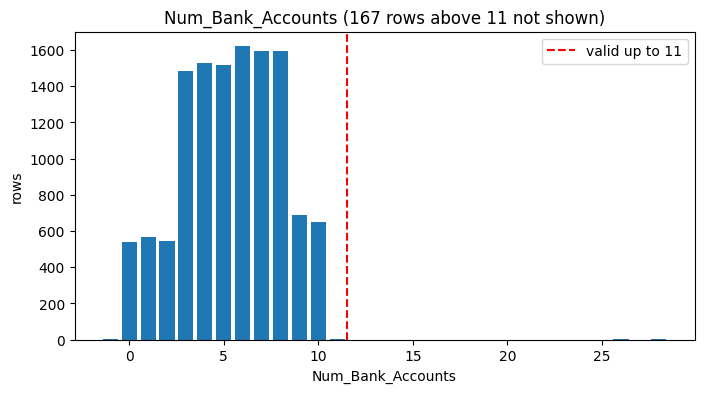

In [47]:
# Num_Bank_Accounts: counts of values up to 40; valid values stop at 11
num_bank_accounts = duckdb.sql("""
    SELECT TRY_CAST(trim(trim(Num_Bank_Accounts), '_') AS DOUBLE) AS value, COUNT(*) AS rows
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    GROUP BY value
    HAVING value BETWEEN -5 AND 40
""").df()
above = range_summary.set_index("column_name").above_range["Num_Bank_Accounts"]

plt.figure(figsize=(8, 4))
plt.bar(num_bank_accounts.value, num_bank_accounts.rows)
plt.axvline(11 + 0.5, color="red", linestyle="--", label="valid up to 11")
plt.title(f"Num_Bank_Accounts ({above} rows above 11 not shown)")
plt.xlabel("Num_Bank_Accounts")
plt.ylabel("rows")
plt.legend()
plt.show()

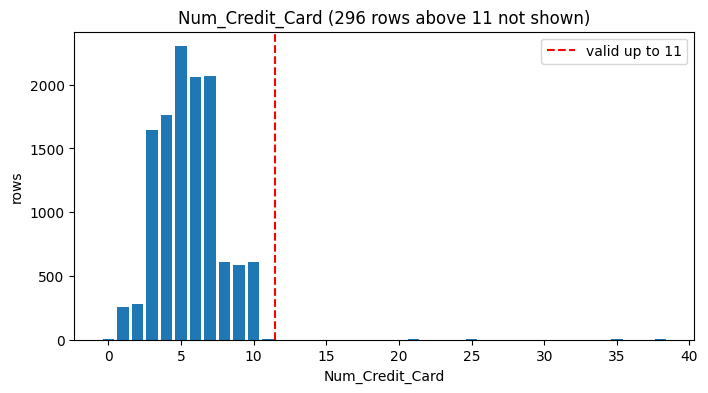

In [39]:
# Num_Credit_Card: counts of values up to 40; valid values stop at 11
num_credit_card = duckdb.sql("""
    SELECT TRY_CAST(trim(trim(Num_Credit_Card), '_') AS DOUBLE) AS value, COUNT(*) AS rows
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    GROUP BY value
    HAVING value BETWEEN -5 AND 40
""").df()
above = range_summary.set_index("column_name").above_range["Num_Credit_Card"]

plt.figure(figsize=(8, 4))
plt.bar(num_credit_card.value, num_credit_card.rows)
plt.axvline(11 + 0.5, color="red", linestyle="--", label="valid up to 11")
plt.title(f"Num_Credit_Card ({above} rows above 11 not shown)")
plt.xlabel("Num_Credit_Card")
plt.ylabel("rows")
plt.legend()
plt.show()

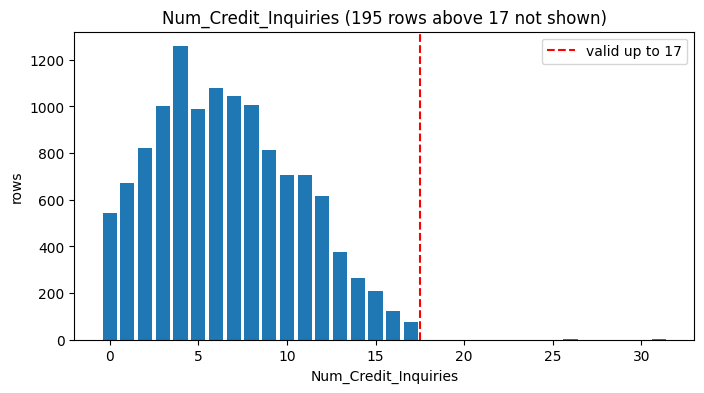

In [40]:
# Num_Credit_Inquiries: counts of values up to 40; valid values stop at 17
num_credit_inquiries = duckdb.sql("""
    SELECT TRY_CAST(trim(trim(Num_Credit_Inquiries), '_') AS DOUBLE) AS value, COUNT(*) AS rows
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    GROUP BY value
    HAVING value BETWEEN -5 AND 40
""").df()
above = range_summary.set_index("column_name").above_range["Num_Credit_Inquiries"]

plt.figure(figsize=(8, 4))
plt.bar(num_credit_inquiries.value, num_credit_inquiries.rows)
plt.axvline(17 + 0.5, color="red", linestyle="--", label="valid up to 17")
plt.title(f"Num_Credit_Inquiries ({above} rows above 17 not shown)")
plt.xlabel("Num_Credit_Inquiries")
plt.ylabel("rows")
plt.legend()
plt.show()

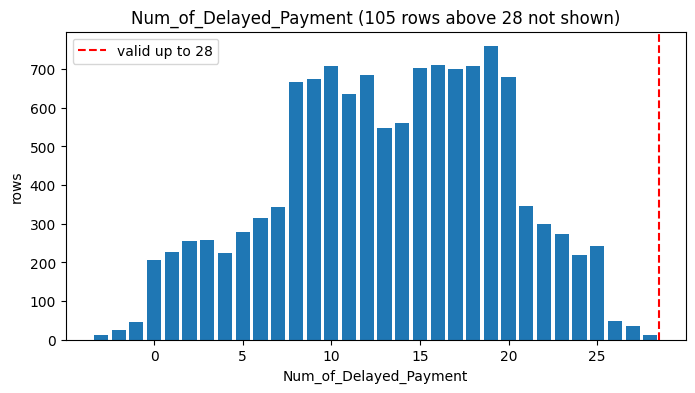

In [41]:
# Num_of_Delayed_Payment: counts of values up to 40; valid values stop at 28
num_of_delayed_payment = duckdb.sql("""
    SELECT TRY_CAST(trim(trim(Num_of_Delayed_Payment), '_') AS DOUBLE) AS value, COUNT(*) AS rows
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    GROUP BY value
    HAVING value BETWEEN -5 AND 40
""").df()
above = range_summary.set_index("column_name").above_range["Num_of_Delayed_Payment"]

plt.figure(figsize=(8, 4))
plt.bar(num_of_delayed_payment.value, num_of_delayed_payment.rows)
plt.axvline(28 + 0.5, color="red", linestyle="--", label="valid up to 28")
plt.title(f"Num_of_Delayed_Payment ({above} rows above 28 not shown)")
plt.xlabel("Num_of_Delayed_Payment")
plt.ylabel("rows")
plt.legend()
plt.show()

In [42]:
# Installments and annual income relative to monthly salary
salary_ratios = duckdb.sql("""
    SELECT
        TRY_CAST(trim(trim(Total_EMI_per_month), '_') AS DOUBLE)
            / TRY_CAST(trim(trim(Monthly_Inhand_Salary), '_') AS DOUBLE) AS emi_to_salary,
        TRY_CAST(trim(trim(Annual_Income), '_') AS DOUBLE)
            / TRY_CAST(trim(trim(Monthly_Inhand_Salary), '_') AS DOUBLE) AS income_to_salary
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
""").df()

duckdb.sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(*) FILTER (WHERE emi_to_salary > 1) AS emi_above_salary,
        COUNT(*) FILTER (WHERE emi_to_salary BETWEEN 0.5 AND 1) AS emi_half_to_full_salary,
        COUNT(*) FILTER (WHERE income_to_salary > 30) AS income_above_30x_salary,
        COUNT(*) FILTER (WHERE income_to_salary BETWEEN 25 AND 30) AS income_25x_to_30x_salary,
        ROUND(MEDIAN(income_to_salary), 1) AS median_income_to_salary
    FROM salary_ratios
""").df()

,rows,emi_above_salary,emi_half_to_full_salary,income_above_30x_salary,income_25x_to_30x_salary,median_income_to_salary
0,12500,397,9,114,0,12.0


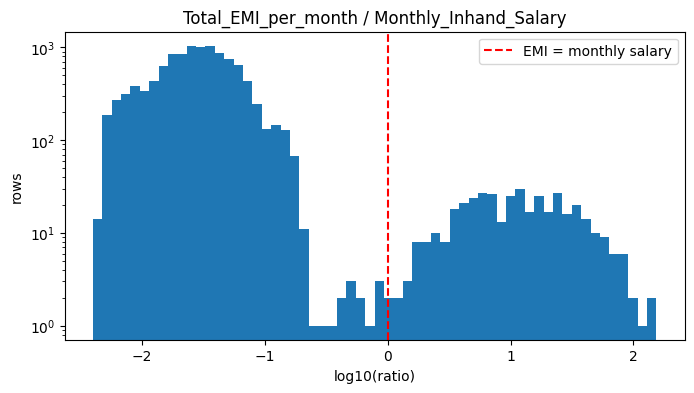

In [43]:
# Total_EMI_per_month / Monthly_Inhand_Salary: normal values sit well below 1; corrupted values sit far above (log scales)
plt.figure(figsize=(8, 4))
plt.hist(np.log10(salary_ratios.emi_to_salary[salary_ratios.emi_to_salary > 0]), bins=60)
plt.axvline(np.log10(1), color="red", linestyle="--", label="EMI = monthly salary")
plt.yscale("log")
plt.title("Total_EMI_per_month / Monthly_Inhand_Salary")
plt.xlabel("log10(ratio)")
plt.ylabel("rows")
plt.legend()
plt.show()

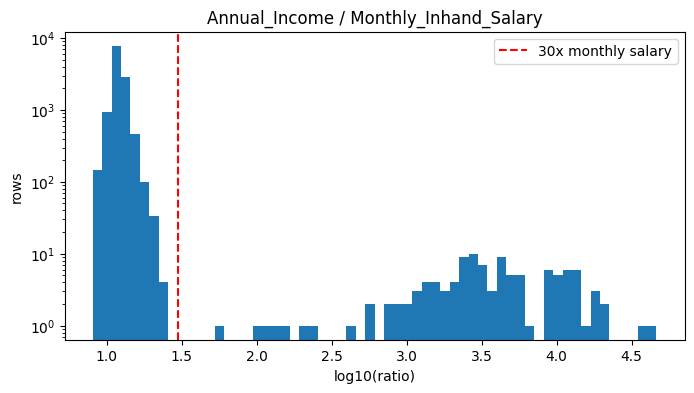

In [44]:
# Annual_Income / Monthly_Inhand_Salary: normal values sit around 12x; corrupted values sit far above 30x (log scales)
plt.figure(figsize=(8, 4))
plt.hist(np.log10(salary_ratios.income_to_salary), bins=60)
plt.axvline(np.log10(30), color="red", linestyle="--", label="30x monthly salary")
plt.yscale("log")
plt.title("Annual_Income / Monthly_Inhand_Salary")
plt.xlabel("log10(ratio)")
plt.ylabel("rows")
plt.legend()
plt.show()

In [45]:
# Monthly_Balance has one placeholder far below every real balance
duckdb.sql("""
    SELECT
        Customer_ID,
        Monthly_Balance AS raw_value,
        TRY_CAST(trim(trim(Monthly_Balance), '_') AS DOUBLE) AS balance
    FROM read_csv_auto('data/features_financials.csv', all_varchar=true)
    ORDER BY balance
    LIMIT 5
""").df()

,Customer_ID,raw_value,balance
0,CUS_0x2f7e,__-333333333333333333333333333__,-3.333333e+26
1,CUS_0xa7b6,0.3825579787828133,3.825580e-01
2,CUS_0xbca6,0.71023971023169,7.102397e-01
3,CUS_0x5ae1,1.5263103256080512,1.526310e+00
4,CUS_0x8e88,1.7799845296881358,1.779985e+00
